<a href="https://colab.research.google.com/github/Briyad37/Convolutional-Neural-Networks-TomatoDoc-Models/blob/main/05_tomato_disease_classification_cnn_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing all the necessary libraries

*   List item
*   List item



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing import image

## Getting the tomato dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_directory_location = '/content/drive/MyDrive/ColabNotebooks/Tomato_disease_detection/tomato_dataset'

## Listing the directories present inside tomato dataset

In [ ]:
os.listdir(dataset_directory_location)

['train', 'test']

## Getting the training,testing and validation directory location

In [1]:
train_dataset_location = os.path.join(dataset_directory_location, 'train')
test_dataset_location = os.path.join(dataset_directory_location, 'test')
validation_dataset_location = os.path.join(dataset_directory_location, 'valid')

NameError: name 'os' is not defined

## Listing all the directories present inside 'train' and 'test' directory respectively

In [ ]:
os.listdir(train_dataset_location)

['Tomato___Tomato_mosaic_virus',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Target_Spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Leaf_Mold',
 'Tomato___Late_blight',
 'Tomato___healthy',
 'Tomato___Early_blight',
 'Tomato___Bacterial_spot']

In [ ]:
os.listdir(test_dataset_location)

['Tomato___Tomato_mosaic_virus',
 'Tomato___Late_blight',
 'Tomato___Target_Spot',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Leaf_Mold',
 'Tomato___healthy',
 'Tomato___Early_blight',
 'Tomato___Bacterial_spot']

In [ ]:
os.listdir(validation_dataset_location)

## Viewing a 'tomato image with bacterial spot image'

In [ ]:
tomato_bacterial_spot_img = os.path.join(train_dataset_location, 'Tomato___Bacterial_spot')

In [ ]:
os.listdir(tomato_bacterial_spot_img)[:1]

['2dce98fb-99da-4f38-8ade-2a9c2dfe6599___GCREC_Bact.Sp 3482.JPG']

In [ ]:
tomato_bacterial_spot_img_read = imread(os.path.join(tomato_bacterial_spot_img, '00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG'))

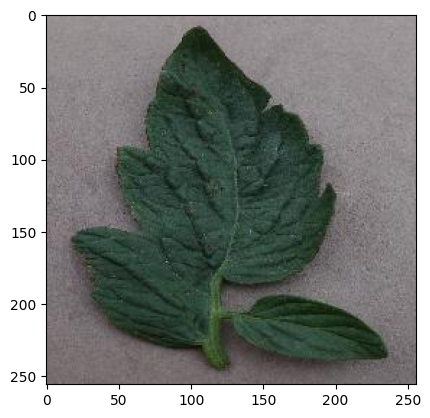

In [ ]:
plt.imshow(tomato_bacterial_spot_img_read)

## Getting the shape of the image

In [ ]:
tomato_bacterial_spot_img_read.shape

(256, 256, 3)

## Setting the right image shape of the image for our use case

In [ ]:
correct_image_shape = (224, 224, 3)

## Performing Data Augmentation

In [2]:
train_image_gen_augmented = ImageDataGenerator(rotation_range=20,
                               width_shift_range=0.1,
                               height_shift_range=0.1,
                               shear_range=0.1,
                               zoom_range=0.1,
                               horizontal_flip=True,
                               fill_mode='nearest',
                               rescale=1./255)

NameError: name 'ImageDataGenerator' is not defined

In [ ]:
validation_test_image_gen_scaled = ImageDataGenerator(rescale=1./255)

In [3]:
train_image_gen = train_image_gen_augmented.flow_from_directory(train_dataset_location,
                                                target_size=correct_image_shape[:2],
                                                color_mode='rgb',
                                                batch_size=16,
                                                class_mode='categorical')

test_image_gen = validation_test_image_gen_scaled.flow_from_directory(test_dataset_location,
                                                target_size=correct_image_shape[:2],
                                                color_mode='rgb',
                                                batch_size=16,
                                                class_mode='categorical')

validation_image_gen = validation_test_image_gen_scaled.flow_from_directory(validation_dataset_location,
                                                target_size=correct_image_shape[:2],
                                                color_mode='rgb',
                                                batch_size=16,
                                                class_mode='categorical')

NameError: name 'train_image_gen_augmented' is not defined

## Creating and training the model

In [ ]:
model = Sequential()

In [ ]:
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=correct_image_shape, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(BatchNormalization())

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 9216)           │        36,864 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │             

 Total params: 1,294,538 (4.94 MB)

 Trainable params: 1,275,274 (4.86 MB)

 Non-trainable params: 19,264 (75.25 KB)

In [ ]:
model.compile(loss=CategoricalCrossentropy(), optimizer=Adam(learning_rate=2e-5), metrics=['accuracy'])

In [ ]:
model.fit(train_image_gen, validation_image_gen, epochs=30)

Epoch 1/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 8374s 8s/step - accuracy: 0.4340 - loss: 1.7443 - val_accuracy: 0.4838 - val_loss: 1.6001
Epoch 2/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 314s 285ms/step - accuracy: 0.6028 - loss: 1.2532 - val_accuracy: 0.5667 - val_loss: 1.3473
Epoch 3/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 311s 282ms/step - accuracy: 0.6619 - loss: 1.0767 - val_accuracy: 0.6135 - val_loss: 1.1909
Epoch 4/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 316s 286ms/step - accuracy: 0.6962 - loss: 0.9640 - val_accuracy: 0.6346 - val_loss: 1.0966
Epoch 5/30
 944/1103 ━━━━━━━━━━━━━━━━━━━━ 40s 254ms/step - accuracy: 0.7232 - loss: 0.8794

In [ ]:
history_df = pd.DataFrame(model.history.history)

In [ ]:
history_df[['loss', 'val_loss']].plot()

In [ ]:
history_df[['accuracy', 'val_accuracy']].plot()

## Calculating the accuracy on training and testing data

In [ ]:
model.evaluate(train_image_gen)[1]

In [ ]:
model.evaluate(test_image_gen)[1]

In [ ]:
model.evaluate(validation_image_gen)[1]

Model Evaluation: Precision, Recall, and F1-Score

In [ ]:
from sklearn.metrics import classification_report

# Get true labels
test_labels = test_image_gen.classes

# Get class names in the order of test_image_gen
class_names_in_order = list(test_image_gen.class_indices.keys())

# Predict probabilities for the test set
predictions = model.predict(test_image_gen)
predicted_classes = np.argmax(predictions, axis=1)

# Generate classification report
report = classification_report(test_labels, predicted_classes, target_names=class_names_in_order)
print(report)

## Making prediction on sample data

In [ ]:
sample_img_load = image.load_img(os.path.join(test_dataset_location, 'Tomato___Tomato_mosaic_virus', 'fcf80369-b340-4a7c-becc-8a600eb73447___PSU_CG 2175.JPG'), target_size=correct_image_shape)

In [ ]:
os.listdir(os.path.join(test_dataset_location, 'Tomato___Tomato_mosaic_virus'))[:5]

In [ ]:
sample_img_load

In [ ]:
sample_img_to_arr = image.img_to_array(sample_img_load) / 255

In [ ]:
sample_img_to_arr_expand_dim = np.expand_dims(sample_img_to_arr, 0)

In [ ]:
prediction = model.predict(sample_img_to_arr_expand_dim)[0]

In [ ]:
pred_result = np.argmax(prediction)

In [ ]:
class_names = ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

In [ ]:
pred_final_result = class_names[pred_result]

In [ ]:
pred_final_result

## Save the model

In [ ]:
save_model(model, '/content/drive/MyDrive/cnnfromscratch_model.keras')

In [ ]:
from google.colab import files

files.download('cnnfromscratch_model.keras')